In [2]:
import sys
sys.path.append('/Users/kellyhui/koskella_lab_notebook')
import pandas as pd

In [22]:
import pandas as pd

dfs_TK = []

for i in range(6):
    file_path = f'TK_P6_2_{i}.csv'
    df = pd.read_csv(file_path)
    df['Population'] = i
    
    # keep only zero-dose rows
    df['H_OD'] = df.groupby(['Population', 'Dose'])['OD'].transform(
        lambda x: x[df.loc[x.index, 'BioRep'] == 'H'].iloc[0]
    )

    # subtract row H
    df['OD_subtracted'] = df['OD'] - df['H_OD']

    # remove row H
    df = df[df['BioRep'] != 'H']

    # keep only zero-dose rows
    df_zero = df[df['Dose'] == 0]
    
    dfs_TK.append(df_zero)

combined_df_TK = pd.concat(dfs_TK, ignore_index=True)
combined_df_TK

,Well,OD,BioRep,Col,Dose,Population,H_OD,OD_subtracted
0,A1,0.9005,A,1,0.0,0,0.1564,0.7441
1,B1,0.7311,B,1,0.0,0,0.1564,0.5747
2,C1,0.8646,C,1,0.0,0,0.1564,0.7082
3,D1,1.0782,D,1,0.0,0,0.1564,0.9218
4,E1,0.8935,E,1,0.0,0,0.1564,0.7371
...,...,...,...,...,...,...,...,...
121,C3,1.0602,C,3,0.0,5,0.1838,0.8764
122,D3,1.1686,D,3,0.0,5,0.1838,0.9848
123,E3,1.1651,E,3,0.0,5,0.1838,0.9813
124,F3,0.9978,F,3,0.0,5,0.1838,0.8140


In [21]:
dfs_PT = []

for i in range(6):
    file_path = f'PT_P6_{i}.csv'
    df = pd.read_csv(file_path)
    df['Population'] = i
    
    df['H_OD'] = df.groupby(['Population', 'Dose'])['OD'].transform(
        lambda x: x[df.loc[x.index, 'BioRep'] == 'H'].iloc[0]
    )

    # subtract row H
    df['OD_subtracted'] = df['OD'] - df['H_OD']

    # remove row H
    df = df[df['BioRep'] != 'H']

    # keep only zero-dose rows
    df_zero = df[df['Dose'] == 0]
    
    dfs_PT.append(df_zero)

combined_df_PT = pd.concat(dfs_PT, ignore_index=True)
combined_df_PT

,Well,OD,BioRep,Col,Dose,Population,H_OD,OD_subtracted
0,A1,0.5051,A,1,0.0,0,0.2029,0.3022
1,B1,0.4496,B,1,0.0,0,0.2029,0.2467
2,C1,0.3103,C,1,0.0,0,0.2029,0.1074
3,D1,0.3791,D,1,0.0,0,0.2029,0.1762
4,E1,0.3926,E,1,0.0,0,0.2029,0.1897
...,...,...,...,...,...,...,...,...
121,C3,0.3063,C,3,0.0,5,0.0983,0.2080
122,D3,0.4192,D,3,0.0,5,0.0983,0.3209
123,E3,0.2967,E,3,0.0,5,0.0983,0.1984
124,F3,0.4126,F,3,0.0,5,0.0983,0.3143


In [32]:
#group by population

population_means_TK = (
    combined_df_TK
    .groupby('Population', as_index=False)['OD_subtracted']
    .mean()
)

population_means_PT = (
    combined_df_PT
    .groupby('Population', as_index=False)['OD_subtracted']
    .mean()
)

population_means_PT

,Population,OD_subtracted
0,0,0.194310
1,1,0.205886
2,2,0.325719
3,3,0.264662
4,4,0.383233
5,5,0.262981


In [33]:
file_path_1 = f'../PT_anc_1.csv'
df_pt_anc = pd.read_csv(file_path_1)

file_path_2 = f'../99TK_anc_1.csv'
df_tk_anc = pd.read_csv(file_path_2)

df_pt_anc

,Time [s],A,B,C,D,E,F,G,H
0,12.001167,0.468167,0.458467,0.4645,0.497833,0.501167,0.507933,0.501867,0.4701


In [35]:
#conv into vectors

pt23_evo_od = population_means_PT["OD_subtracted"].values
tk_evo_od = population_means_TK["OD_subtracted"].values
pt23_anc_od = df_pt_anc[["A","B","C","D","E","F","G"]].values.flatten()
tk_anc_od = df_tk_anc[["A","B","C","D","E","F","G"]].values.flatten()

In [36]:
#build df

pt23_data = pd.DataFrame({
    "Strain": "PT23",
    "Group": (
        ["Ancestor"] * len(pt23_anc_od) +
        ["Evolved"] * len(pt23_evo_od)
    ),
    "OD": (
        list(pt23_anc_od) +
        list(pt23_evo_od)
    )
})

tk_data = pd.DataFrame({
    "Strain": "99TK",
    "Group": (
        ["Ancestor"] * len(tk_anc_od) +
        ["Evolved"] * len(tk_evo_od)
    ),
    "OD": (
        list(tk_anc_od) +
        list(tk_evo_od)
    )
})

data = pd.concat([pt23_data, tk_data], ignore_index=True)

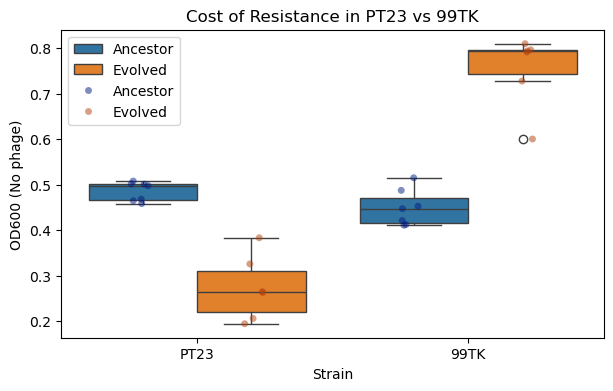

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

sns.boxplot(data=data, x="Strain", y="OD", hue="Group")
sns.stripplot(
    data=data,
    x="Strain",
    y="OD",
    hue="Group",
    dodge=True,
    palette="dark",
    alpha=0.5
)

plt.ylabel("OD600 (No phage)")
plt.title("Cost of Resistance in PT23 vs 99TK")
plt.legend(title="")
plt.show()

In [38]:
from scipy.stats import f_oneway

pt23_anc = data[(data["Strain"]=="PT23") & (data["Group"]=="Ancestor")]["OD"]
pt23_evo = data[(data["Strain"]=="PT23") & (data["Group"]=="Evolved")]["OD"]

f_oneway(pt23_anc, pt23_evo)

F_onewayResult(statistic=np.float64(56.6479850122046), pvalue=np.float64(1.1611440296898853e-05))

In [39]:
tk_anc = data[(data["Strain"]=="99TK") & (data["Group"]=="Ancestor")]["OD"]
tk_evo = data[(data["Strain"]=="99TK") & (data["Group"]=="Evolved")]["OD"]

f_oneway(tk_anc, tk_evo)

F_onewayResult(statistic=np.float64(78.73313175644213), pvalue=np.float64(2.4078959836441815e-06))

In [40]:
pt23_evo = data[(data["Strain"]=="PT23") & (data["Group"]=="Evolved")]["OD"]
tk_evo = data[(data["Strain"]=="99TK") & (data["Group"]=="Evolved")]["OD"]

f_oneway(pt23_evo, tk_evo)

F_onewayResult(statistic=np.float64(119.4396227128679), pvalue=np.float64(7.002231260565789e-07))